In [1]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 35.8 MB/s eta 0:00:00


# Import Library

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    auc
)
from sklearn.preprocessing import LabelBinarizer

# Import Data Setelah IPCA

In [3]:
import pandas as pd

train = pd.read_csv('/kaggle/input/datasets/eliameylanis/datahasilipcaa/train_ipca_with_class (3).csv')
val   = pd.read_csv('/kaggle/input/datasets/eliameylanis/datahasilipcaa/val_ipca_with_class (3).csv')
test  = pd.read_csv('/kaggle/input/datasets/eliameylanis/datahasilipcaa/test_ipca_with_class (3).csv')

X_train = train.drop('Class', axis=1)
y_train = train['Class']

X_val = val.drop('Class', axis=1)
y_val = val['Class']

X_test = test.drop('Class', axis=1)
y_test = test['Class']

# Gabung train + val untuk final model
X_train_full = pd.concat([X_train, X_val], axis=0)
y_train_full = pd.concat([y_train, y_val], axis=0)

# Tampilkan Data

In [4]:
# Gabungkan kembali fitur dan label untuk ditampilkan
train_display = pd.concat([X_train, y_train], axis=1)

print("="*60)
print("5 DATA TRAIN PERTAMA")
print("="*60)
display(train_display.head(5))

print("\n" + "="*60)
print("5 DATA TRAIN TERAKHIR")
print("="*60)
display(train_display.tail(5))

5 DATA TRAIN PERTAMA


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC1815,PC1816,PC1817,PC1818,PC1819,PC1820,PC1821,PC1822,PC1823,Class
0,-6.923188,-3.057075,2.302811,0.350649,1.129448,2.956892,-1.217059,4.546788,-0.703754,-3.417988,...,-0.483277,-0.402347,-0.192478,0.390833,0.413316,-0.253448,-0.073264,0.502254,0.061917,Symbiobacteriia
1,-2.259415,-5.444427,1.548582,-4.380987,2.177188,-1.482424,-5.248405,-0.195862,-3.961524,0.058551,...,-1.432762,0.920800,-0.895003,-0.222368,-0.759301,1.094175,-0.891554,-0.521520,-0.036071,JS1
2,-8.270559,-9.183219,6.027219,27.430165,-10.401908,-0.043881,1.182228,0.403495,0.182646,0.269625,...,-0.081419,0.094647,0.348028,0.090181,-0.303312,-0.191848,0.483196,0.120580,0.832056,Clostridia
3,-8.217937,-9.136481,5.567252,28.387911,-10.687765,1.317543,2.777620,-0.112184,0.216773,0.270551,...,-0.263237,-0.278834,-0.382280,-0.065768,0.205833,-0.502935,-1.036132,0.158779,0.108461,Clostridia
4,0.027436,9.121512,0.622368,-2.195903,-0.364035,-0.308743,-0.321061,3.487489,0.639705,-4.045421,...,-1.410756,0.269713,-1.288333,-0.107718,0.891676,0.749449,-0.327507,0.190938,-1.005441,Gammaproteobacteria



5 DATA TRAIN TERAKHIR


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC1815,PC1816,PC1817,PC1818,PC1819,PC1820,PC1821,PC1822,PC1823,Class
194304,25.656942,-4.599977,0.031800,0.065622,-0.465825,-0.135974,3.927445,-4.481068,-2.957575,-1.121431,...,0.399389,0.885750,0.807552,-1.055973,-0.308885,1.014692,-0.757186,0.319995,0.625101,Bacteroidia
194305,-6.949426,-7.307193,-2.894117,4.021582,1.047587,-0.594862,-1.619099,-3.110970,-1.474992,-4.354319,...,-0.340427,0.159381,-0.370999,-0.380026,0.151349,-0.093096,-0.085815,0.842144,0.358467,Desulfitobacteriia
194306,21.030465,-3.341104,0.134294,-2.536006,-0.309184,0.978852,0.629802,3.825288,-0.328333,-2.074224,...,1.273384,-0.765040,0.282629,-0.054101,0.323531,-0.431939,-0.321558,-1.043033,-0.882744,Bacteroidia
194307,-5.101624,-6.701122,3.892599,5.516173,1.162578,-1.206012,-6.327604,-1.691966,3.657281,-0.980018,...,-0.287473,1.612085,0.352405,-0.259823,-0.417085,0.665776,0.143622,0.186814,-0.082895,Clostridia
194308,-2.811250,5.860282,-3.710480,4.091265,18.844439,-0.365870,9.508273,-2.323792,2.986458,-0.488506,...,0.199375,0.824042,0.623692,0.443981,-0.679027,-0.130997,0.142646,-0.466988,0.206689,Alphaproteobacteria


In [5]:
# Gabungkan kembali fitur dan label untuk ditampilkan
train_display = pd.concat([X_train, y_train], axis=1)

# Ubah index mulai dari 1
train_display.index = train_display.index + 1

print("="*60)
print("5 DATA TRAIN PERTAMA")
print("="*60)
display(train_display.head(5))

print("\n" + "="*60)
print("5 DATA TRAIN TERAKHIR")
print("="*60)
display(train_display.tail(5))

5 DATA TRAIN PERTAMA


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC1815,PC1816,PC1817,PC1818,PC1819,PC1820,PC1821,PC1822,PC1823,Class
1,-6.923188,-3.057075,2.302811,0.350649,1.129448,2.956892,-1.217059,4.546788,-0.703754,-3.417988,...,-0.483277,-0.402347,-0.192478,0.390833,0.413316,-0.253448,-0.073264,0.502254,0.061917,Symbiobacteriia
2,-2.259415,-5.444427,1.548582,-4.380987,2.177188,-1.482424,-5.248405,-0.195862,-3.961524,0.058551,...,-1.432762,0.920800,-0.895003,-0.222368,-0.759301,1.094175,-0.891554,-0.521520,-0.036071,JS1
3,-8.270559,-9.183219,6.027219,27.430165,-10.401908,-0.043881,1.182228,0.403495,0.182646,0.269625,...,-0.081419,0.094647,0.348028,0.090181,-0.303312,-0.191848,0.483196,0.120580,0.832056,Clostridia
4,-8.217937,-9.136481,5.567252,28.387911,-10.687765,1.317543,2.777620,-0.112184,0.216773,0.270551,...,-0.263237,-0.278834,-0.382280,-0.065768,0.205833,-0.502935,-1.036132,0.158779,0.108461,Clostridia
5,0.027436,9.121512,0.622368,-2.195903,-0.364035,-0.308743,-0.321061,3.487489,0.639705,-4.045421,...,-1.410756,0.269713,-1.288333,-0.107718,0.891676,0.749449,-0.327507,0.190938,-1.005441,Gammaproteobacteria



5 DATA TRAIN TERAKHIR


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC1815,PC1816,PC1817,PC1818,PC1819,PC1820,PC1821,PC1822,PC1823,Class
194305,25.656942,-4.599977,0.031800,0.065622,-0.465825,-0.135974,3.927445,-4.481068,-2.957575,-1.121431,...,0.399389,0.885750,0.807552,-1.055973,-0.308885,1.014692,-0.757186,0.319995,0.625101,Bacteroidia
194306,-6.949426,-7.307193,-2.894117,4.021582,1.047587,-0.594862,-1.619099,-3.110970,-1.474992,-4.354319,...,-0.340427,0.159381,-0.370999,-0.380026,0.151349,-0.093096,-0.085815,0.842144,0.358467,Desulfitobacteriia
194307,21.030465,-3.341104,0.134294,-2.536006,-0.309184,0.978852,0.629802,3.825288,-0.328333,-2.074224,...,1.273384,-0.765040,0.282629,-0.054101,0.323531,-0.431939,-0.321558,-1.043033,-0.882744,Bacteroidia
194308,-5.101624,-6.701122,3.892599,5.516173,1.162578,-1.206012,-6.327604,-1.691966,3.657281,-0.980018,...,-0.287473,1.612085,0.352405,-0.259823,-0.417085,0.665776,0.143622,0.186814,-0.082895,Clostridia
194309,-2.811250,5.860282,-3.710480,4.091265,18.844439,-0.365870,9.508273,-2.323792,2.986458,-0.488506,...,0.199375,0.824042,0.623692,0.443981,-0.679027,-0.130997,0.142646,-0.466988,0.206689,Alphaproteobacteria


# 1. K-Nearest Neighbors

# Mencari Nilai K untuk KNN

In [6]:
from sklearn.model_selection import ParameterGrid
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import time

print("=" * 70)
print("KNN + PARAMETER GRID (weights = distance, metric = euclidean)")
print("=" * 70)

# Definisi grid hyperparameter
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['distance'],   # menggunakan bobot jarak
    'metric': ['euclidean']    # jarak Euclidean
}

grid = ParameterGrid(param_grid)

# Variabel untuk menyimpan hasil terbaik
best_acc_knn = 0
best_params_knn = None
best_model_knn = None
results_knn = []

start_total_knn = time.time()

for params in grid:
    print(f"\nTraining dengan parameter: {params}")
    
    start_time = time.time()
    
    # Training model pakai data train
    model = KNeighborsClassifier(**params)
    model.fit(X_train, y_train)
    
    # Evaluasi model pakai data validation
    y_val_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_val_pred)
    
    duration = time.time() - start_time
    
    print(f"  -> Validation Accuracy : {acc:.4f}")
    print(f"  -> Waktu Training      : {duration:.2f} detik")
    
    # Simpan hasil
    results_knn.append((params['n_neighbors'], acc))
    
    # Update best model jika akurasi lebih tinggi
    if acc > best_acc_knn:
        best_acc_knn = acc
        best_params_knn = params
        best_model_knn = model

end_total_knn = time.time()
duration_knn = end_total_knn - start_total_knn

print("\n" + "-" * 70)
print(f"Best Parameters KNN  : {best_params_knn}")
print(f"Best Validation Acc  : {best_acc_knn:.4f}")
print(f"Total Waktu Eksekusi : {duration_knn:.2f} detik")
print("-" * 70)

KNN + PARAMETER GRID (weights = distance, metric = euclidean)

Training dengan parameter: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
  -> Validation Accuracy : 0.9909
  -> Waktu Training      : 352.33 detik

Training dengan parameter: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'distance'}
  -> Validation Accuracy : 0.9892
  -> Waktu Training      : 351.71 detik

Training dengan parameter: {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'distance'}
  -> Validation Accuracy : 0.9876
  -> Waktu Training      : 341.85 detik

Training dengan parameter: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'distance'}
  -> Validation Accuracy : 0.9862
  -> Waktu Training      : 343.85 detik

Training dengan parameter: {'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'distance'}
  -> Validation Accuracy : 0.9845
  -> Waktu Training      : 346.14 detik

----------------------------------------------------------------------
Best Parameters KNN  : {'metri

# Visualisasi Akurasi Nilai K Terbaik

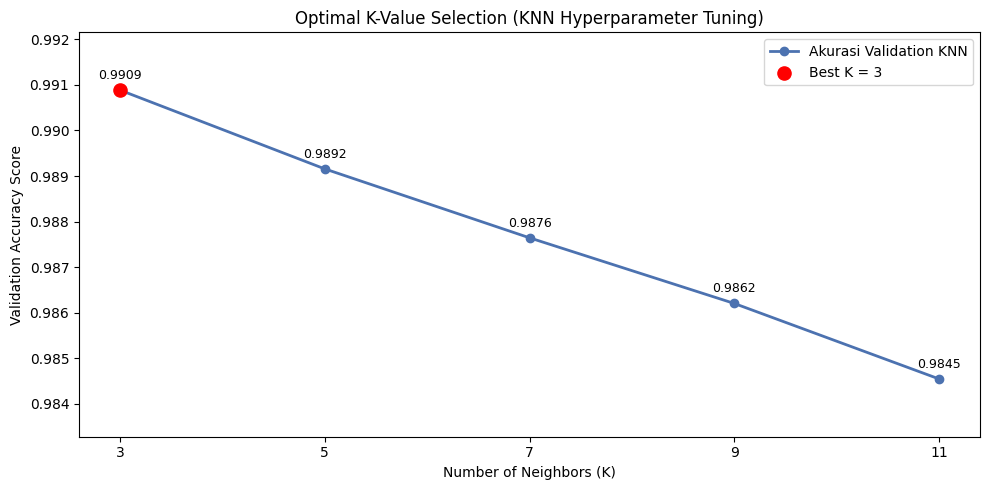

In [7]:
# DataFrame KNN
results_df_knn = pd.DataFrame(results_knn, columns=["k", "accuracy"])

plt.figure(figsize=(10, 5))
plt.style.use("default")

# Warna seperti sebelumnya
main_color = "#4C72B0"
best_color = "red"

# Plot line utama
plt.plot(results_df_knn["k"],
         results_df_knn["accuracy"],
         marker="o",
         markersize=6,
         linewidth=2,
         color=main_color,
         label="Akurasi Validation KNN")

# Highlight Best K
plt.scatter(best_params_knn["n_neighbors"],
            best_acc_knn,
            color=best_color,
            s=90,
            zorder=5,
            label=f"Best K = {best_params_knn['n_neighbors']}")

# Rentang Y lebih proporsional & rapi
min_acc = results_df_knn["accuracy"].min()
max_acc = results_df_knn["accuracy"].max()
padding = (max_acc - min_acc) * 0.2   # 20% ruang atas-bawah

plt.ylim(min_acc - padding, max_acc + padding)

# Label angka akurasi
for x, y in zip(results_df_knn["k"], results_df_knn["accuracy"]):
    plt.annotate(f"{y:.4f}",
                 (x, y),
                 textcoords="offset points",
                 xytext=(0, 8),
                 ha="center",
                 fontsize=9)

plt.title("Optimal K-Value Selection (KNN Hyperparameter Tuning)")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Validation Accuracy Score")
plt.xticks(results_df_knn["k"])

plt.legend()
plt.tight_layout()
plt.savefig("knn_tuning_result1.png", dpi=300)
plt.show()

# Akurasi KNN

In [8]:
print("\n" + "=" * 70)
print("FINAL TRAINING (Train + Validation) - K-Nearest Neighbors")
print("=" * 70)

# 1. Gunakan best_params_knn yang sudah spesifik hasil tuning KNN
# 2. Train ulang pada data gabungan (Train + Validation)
final_knn = KNeighborsClassifier(**best_params_knn)
final_knn.fit(X_train_full, y_train_full)

# 3. Prediksi pada Test Set (Data yang benar-benar baru)
# Kita beri nama spesifik y_test_pred_knn agar tidak tertimpa GNB
y_test_pred_knn = final_knn.predict(X_test)

# 4. Hitung akurasi test khusus KNN
test_acc_knn = accuracy_score(y_test, y_test_pred_knn)

print(f"Model KNN yang digunakan    : {best_params_knn}")
print(f"Test Accuracy (Final Model) : {test_acc_knn:.4f}")
print("=" * 70)


FINAL TRAINING (Train + Validation) - K-Nearest Neighbors
Model KNN yang digunakan    : {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
Test Accuracy (Final Model) : 0.9912


# Confusion Matriks KNN

In [9]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, roc_auc_score, classification_report

print("\n" + "=" * 70)
print("EVALUASI MODEL AKHIR - K-Nearest Neighbors (Data Test)")
print("=" * 70)

# 1. Gunakan model final_knn (hasil training X_train_full)
y_test_pred_knn = final_knn.predict(X_test)
y_test_prob_knn = final_knn.predict_proba(X_test)

# 2. Confusion Matrix khusus KNN
cm_knn = confusion_matrix(y_test, y_test_pred_knn)

# 3. Metrik Evaluasi (Weighted untuk Multiclass)
precision_knn = precision_score(y_test, y_test_pred_knn, average='weighted')
recall_knn = recall_score(y_test, y_test_pred_knn, average='weighted')
roc_auc_knn = roc_auc_score(y_test, y_test_prob_knn, multi_class='ovr', average='weighted')

print("Confusion Matrix (KNN):")
print(cm_knn)

print("\nMetrik Ringkasan (Data Test):")
print(f"Precision : {precision_knn:.4f}")
print(f"Recall    : {recall_knn:.4f}")
print(f"ROC AUC   : {roc_auc_knn:.4f}")

print("\nClassification Report KNN:")
print(classification_report(y_test, y_test_pred_knn))

print("=" * 70)


EVALUASI MODEL AKHIR - K-Nearest Neighbors (Data Test)
Confusion Matrix (KNN):
[[13  0  0 ...  0  0  0]
 [ 0 66  0 ...  0  0  0]
 [ 0  0 17 ...  0  0  0]
 ...
 [ 0  0  0 ... 37  0  0]
 [ 0  0  0 ...  0 51  0]
 [ 0  0  0 ...  0  0 60]]

Metrik Ringkasan (Data Test):
Precision : 0.9913
Recall    : 0.9912
ROC AUC   : 0.9971

Classification Report KNN:
                               precision    recall  f1-score   support

                       4-29-1       0.93      1.00      0.96        13
                         ABY1       1.00      0.87      0.93        76
                          AD3       1.00      0.94      0.97        18
               Abditibacteria       1.00      1.00      1.00        32
                Acetothermiia       1.00      0.97      0.98        32
               Acidimicrobiia       0.99      0.99      0.99       480
               Acidobacteriae       1.00      0.99      1.00       641
               Actinobacteria       0.99      1.00      1.00      3600
        

# Data Frame Aktual Prediksi

In [10]:
df_pred = pd.DataFrame({
    'Aktual': y_test,
    'Prediksi': y_test_pred_knn
})

# Ubah index mulai dari 1
df_pred.index = df_pred.index + 1

df_pred.head(10)

,Aktual,Prediksi
1,Gammaproteobacteria,Gammaproteobacteria
2,Bacilli,Bacilli
3,Desulfobulbia,Desulfobulbia
4,Clostridia,Clostridia
5,Gammaproteobacteria,Gammaproteobacteria
6,Alphaproteobacteria,Alphaproteobacteria
7,Kiritimatiellae,Kiritimatiellae
8,Alphaproteobacteria,Alphaproteobacteria
9,Actinobacteria,Actinobacteria
10,Gammaproteobacteria,Gammaproteobacteria


In [11]:
df_pred = pd.DataFrame({
    'Aktual': y_test,
    'Prediksi': y_test_pred_knn
})

# Ubah index mulai dari 1
df_pred.index = df_pred.index + 1

df_pred.tail(10)

,Aktual,Prediksi
55509,Gammaproteobacteria,Gammaproteobacteria
55510,Bacteroidia,Bacteroidia
55511,Bacilli,Bacilli
55512,Desulfobacteria,Desulfobacteria
55513,Bacteroidia,Bacteroidia
55514,Cyanobacteriia,Cyanobacteriia
55515,Bacilli,Bacilli
55516,Planctomycetes,Planctomycetes
55517,Bacilli,Bacilli
55518,Gammaproteobacteria,Gammaproteobacteria


# Visualisasi Confusion Matrix KNN


CONFUSION MATRIX KNN (10 KELAS TERATAS)


,4-29-1,ABY1,AD3,Abditibacteria,Acetothermiia,Acidimicrobiia,Acidobacteriae,Actinobacteria,Aerophobia,Alphaproteobacteria
4-29-1,13,0,0,0,0,0,0,0,0,0
ABY1,0,66,0,0,0,0,0,0,0,1
AD3,0,0,17,0,0,0,0,0,0,0
Abditibacteria,0,0,0,32,0,0,0,0,0,0
Acetothermiia,0,0,0,0,31,0,0,0,0,0
Acidimicrobiia,0,0,0,0,0,474,0,3,0,0
Acidobacteriae,1,0,0,0,0,0,637,0,0,0
Actinobacteria,0,0,0,0,0,0,0,3593,0,0
Aerophobia,0,0,0,0,0,0,0,0,13,0
Alphaproteobacteria,0,0,0,0,0,1,0,0,0,4511



CONFUSION MATRIX KNN (10 KELAS TERBAWAH)


,Vicinamibacteria,WCHB1-81,WOR-1,WPS-2,WS1,WS2,Zetaproteobacteria,Zixibacteria,bacteriap25,vadinHA49
Vicinamibacteria,278,0,0,0,0,0,0,0,0,0
WCHB1-81,0,17,0,0,0,0,0,0,0,0
WOR-1,0,0,6,0,0,0,0,0,0,0
WPS-2,0,0,0,9,0,0,0,0,0,0
WS1,0,0,0,0,14,0,0,0,0,0
WS2,0,0,0,0,0,10,0,0,0,0
Zetaproteobacteria,0,0,0,0,0,0,24,0,0,0
Zixibacteria,0,0,0,0,0,0,0,37,0,0
bacteriap25,0,0,0,0,0,0,0,0,51,0
vadinHA49,0,0,0,0,0,0,0,0,0,60


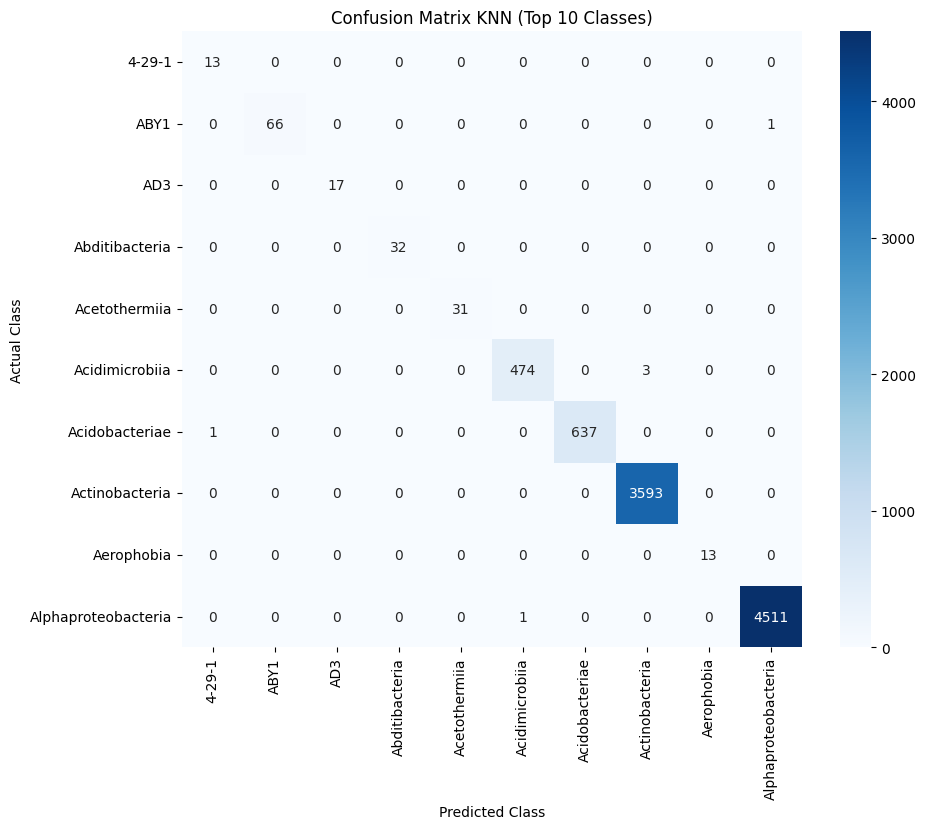

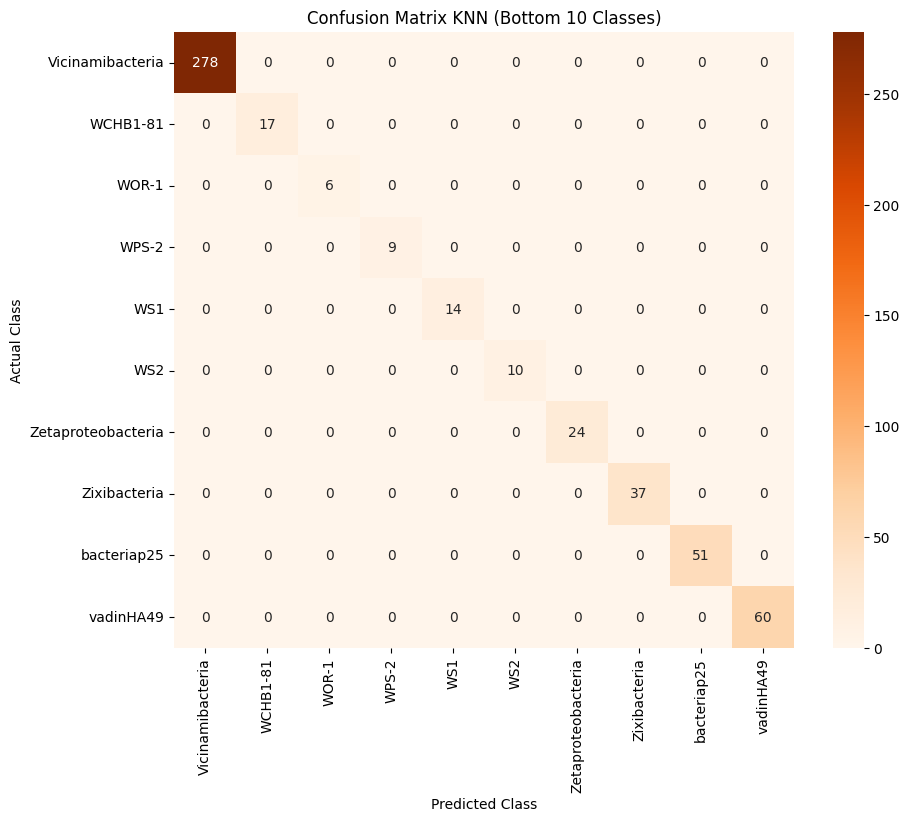


File berhasil disimpan di Kaggle:
/kaggle/working/confusion_matrix_knn_top10.png
/kaggle/working/confusion_matrix_knn_bottom10.png


In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# CONFUSION MATRIX (KNN)
# =========================

cm = cm_knn
labels = sorted(set(y_test))

cm_df = pd.DataFrame(cm, index=labels, columns=labels)

print("\n" + "="*70)
print("CONFUSION MATRIX KNN (10 KELAS TERATAS)")
print("="*70)

cm_top10 = cm_df.iloc[:10, :10]
display(cm_top10)

print("\n" + "="*70)
print("CONFUSION MATRIX KNN (10 KELAS TERBAWAH)")
print("="*70)

cm_bottom10 = cm_df.iloc[-10:, -10:]
display(cm_bottom10)

# =========================
# HEATMAP TOP 10
# =========================
plt.figure(figsize=(10,8))

sns.heatmap(
    cm_top10,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix KNN (Top 10 Classes)")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

# simpan ke kaggle
plt.savefig("/kaggle/working/confusion_matrix_knn_top10.png", dpi=300, bbox_inches="tight")

plt.show()


# =========================
# HEATMAP BOTTOM 10
# =========================
plt.figure(figsize=(10,8))

sns.heatmap(
    cm_bottom10,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("Confusion Matrix KNN (Bottom 10 Classes)")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

# simpan ke kaggle
plt.savefig("/kaggle/working/confusion_matrix_knn_bottom10.png", dpi=300, bbox_inches="tight")

plt.show()


print("\nFile berhasil disimpan di Kaggle:")
print("/kaggle/working/confusion_matrix_knn_top10.png")
print("/kaggle/working/confusion_matrix_knn_bottom10.png")

# Visualisasi ROC AUC per Kelas (KNN)

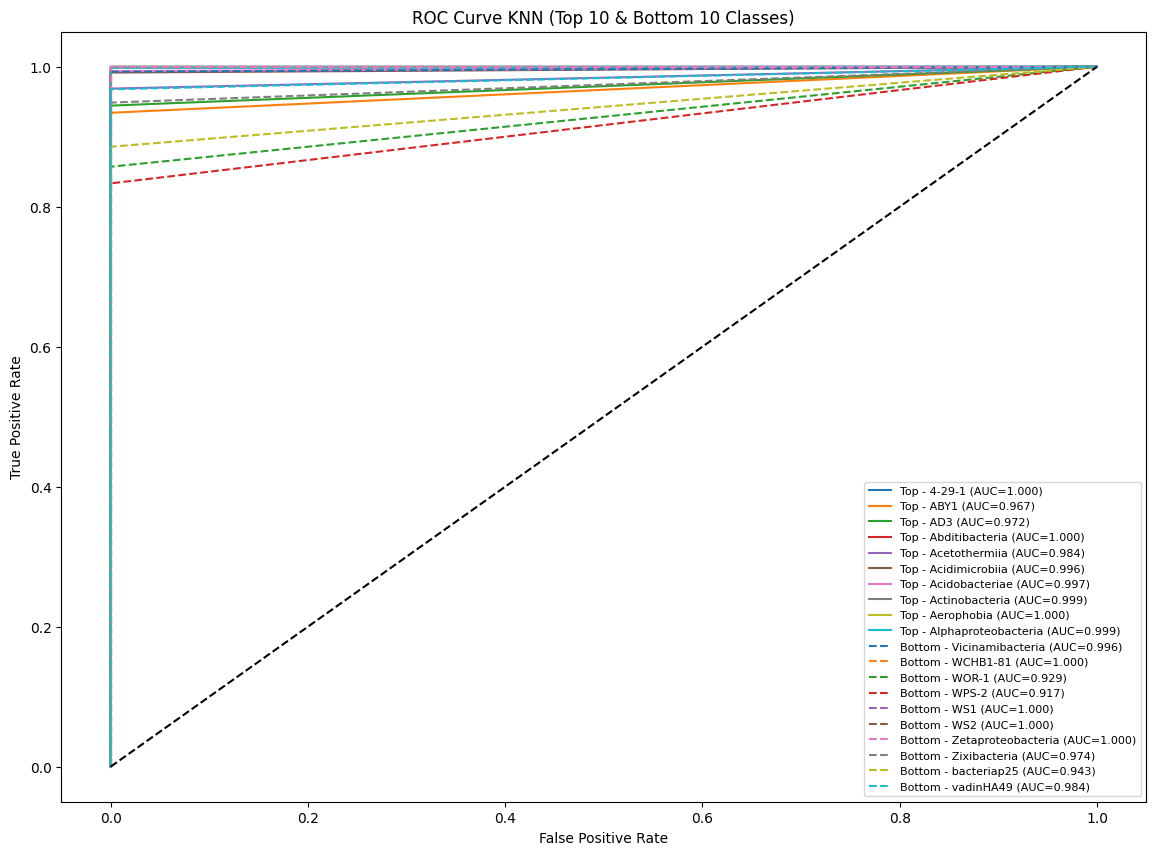

ROC curve tersimpan di: /kaggle/working/roc_knn_top_bottom_classes.png


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# =========================
# SETUP KELAS
# =========================
classes = final_knn.classes_

top10_classes = classes[:10]
bottom10_classes = classes[-10:]

plt.figure(figsize=(14,10))

# =========================
# ROC TOP 10
# =========================
for cls in top10_classes:
    
    idx = np.where(classes == cls)[0][0]
    
    y_true = (y_test == cls).astype(int)
    y_score = y_test_prob_knn[:, idx]

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Top - {cls} (AUC={roc_auc:.3f})")

# =========================
# ROC BOTTOM 10
# =========================
for cls in bottom10_classes:
    
    idx = np.where(classes == cls)[0][0]

    y_true = (y_test == cls).astype(int)
    y_score = y_test_prob_knn[:, idx]

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, linestyle="--", label=f"Bottom - {cls} (AUC={roc_auc:.3f})")

# garis random classifier
plt.plot([0,1],[0,1],'k--')

plt.title("ROC Curve KNN (Top 10 & Bottom 10 Classes)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend(fontsize=8)

# =========================
# SIMPAN DI KAGGLE
# =========================
plt.savefig("/kaggle/working/roc_knn_top_bottom_classes.png", dpi=300, bbox_inches="tight")

plt.show()

print("ROC curve tersimpan di: /kaggle/working/roc_knn_top_bottom_classes.png")

# 2. Gaussian Naive Bayes

# Mencari Parameter Terbaik (Var Smooth)

In [14]:
print("=" * 70)
print("GAUSSIAN NAIVE BAYES + PARAMETER GRID (var_smoothing)")
print("=" * 70)

# range smoothing 10^-9 sampai 10^-2
param_grid = {
    'var_smoothing': np.logspace(-9, -2, 8)
}

grid = ParameterGrid(param_grid)

# Variabel khusus untuk GNB agar tidak tertimpa model lain
best_acc_gnb = 0
best_params_gnb = None
best_model_gnb = None
results_gnb = []

# Catat waktu awal total GNB
start_total_gnb = time.time()

for params in grid:
    print(f"\nTraining dengan parameter: {params}")
    
    start_time = time.time()
    
    model = GaussianNB(**params)
    model.fit(X_train, y_train)
    
    y_val_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_val_pred)
    
    duration = time.time() - start_time
    
    print(f"  -> Validation Accuracy : {acc:.4f}")
    print(f"  -> Waktu Training      : {duration:.4f} detik")
    
    results_gnb.append((params['var_smoothing'], acc))
    
    # Update skor terbaik khusus GNB
    if acc > best_acc_gnb:
        best_acc_gnb = acc
        best_params_gnb = params
        best_model_gnb = model

# Catat waktu akhir total GNB
end_total_gnb = time.time()

# SIMPAN DURASI KE VARIABEL KHUSUS (Penting untuk tabel perbandingan)
duration_gnb = end_total_gnb - start_total_gnb

print("\n" + "-" * 70)
print(f"Best Parameters GNB  : {best_params_gnb}")
print(f"Best Validation Acc  : {best_acc_gnb:.4f}")
print(f"Total Waktu Eksekusi : {duration_gnb:.4f} detik")
print("-" * 70)

GAUSSIAN NAIVE BAYES + PARAMETER GRID (var_smoothing)

Training dengan parameter: {'var_smoothing': np.float64(1e-09)}
  -> Validation Accuracy : 0.8325
  -> Waktu Training      : 75.6425 detik

Training dengan parameter: {'var_smoothing': np.float64(1e-08)}
  -> Validation Accuracy : 0.8325
  -> Waktu Training      : 66.9583 detik

Training dengan parameter: {'var_smoothing': np.float64(1e-07)}
  -> Validation Accuracy : 0.8325
  -> Waktu Training      : 65.6763 detik

Training dengan parameter: {'var_smoothing': np.float64(1e-06)}
  -> Validation Accuracy : 0.8325
  -> Waktu Training      : 65.6356 detik

Training dengan parameter: {'var_smoothing': np.float64(1e-05)}
  -> Validation Accuracy : 0.8329
  -> Waktu Training      : 65.4339 detik

Training dengan parameter: {'var_smoothing': np.float64(0.0001)}
  -> Validation Accuracy : 0.8357
  -> Waktu Training      : 64.8744 detik

Training dengan parameter: {'var_smoothing': np.float64(0.001)}
  -> Validation Accuracy : 0.8550
  -> W

# Visualisasi Akurasi Terbaik Hyperparameter GNB

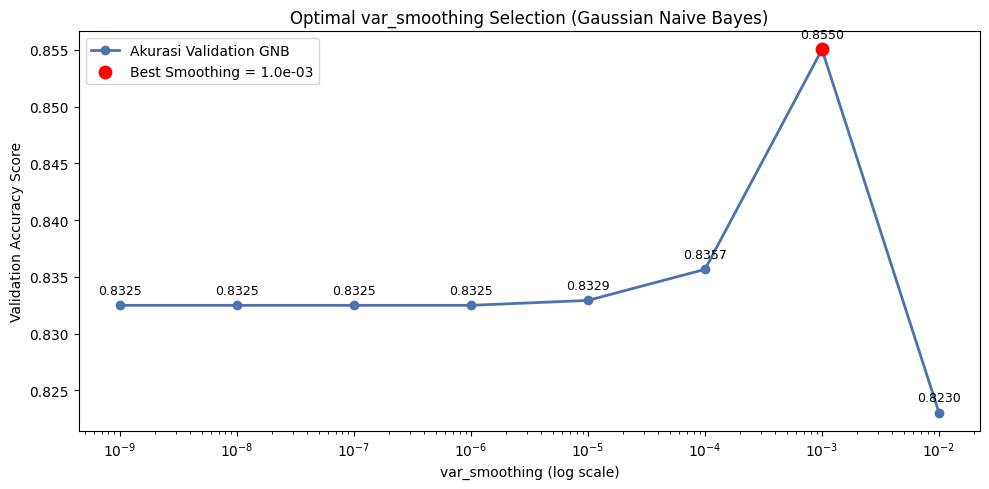

In [15]:
# Pastikan results_gnb sudah dalam bentuk DataFrame
results_df_gnb = pd.DataFrame(results_gnb, columns=["var_smoothing", "accuracy"])

plt.figure(figsize=(10, 5))

# Background putih polos
plt.style.use('default')
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['figure.facecolor'] = 'white'

# Plot garis utama menggunakan data GNB
plt.plot(results_df_gnb["var_smoothing"],
         results_df_gnb["accuracy"],
         marker='o',
         markersize=6,
         linewidth=2,
         color='#4C72B0',
         label="Akurasi Validation GNB")

# Highlight Best var_smoothing menggunakan variabel GNB
plt.scatter(best_params_gnb['var_smoothing'],
            best_acc_gnb,
            color='red',
            s=80,
            zorder=5,
            label=f"Best Smoothing = {best_params_gnb['var_smoothing']:.1e}")

# Tampilkan nilai akurasi di atas titik
for i in range(len(results_df_gnb)):
    plt.text(results_df_gnb["var_smoothing"][i],
             results_df_gnb["accuracy"][i] + 0.0010,
             f"{results_df_gnb['accuracy'][i]:.4f}",
             ha='center',
             fontsize=9)

# Penting! Karena range smoothing menggunakan np.logspace
plt.xscale("log")

plt.title("Optimal var_smoothing Selection (Gaussian Naive Bayes)", fontsize=12)
plt.xlabel("var_smoothing (log scale)")
plt.ylabel("Validation Accuracy Score")

# Simpan dengan nama file yang spesifik
plt.savefig("gnb_parameter_optimized.png", dpi=300, bbox_inches='tight')

plt.legend()
plt.tight_layout()
plt.show()

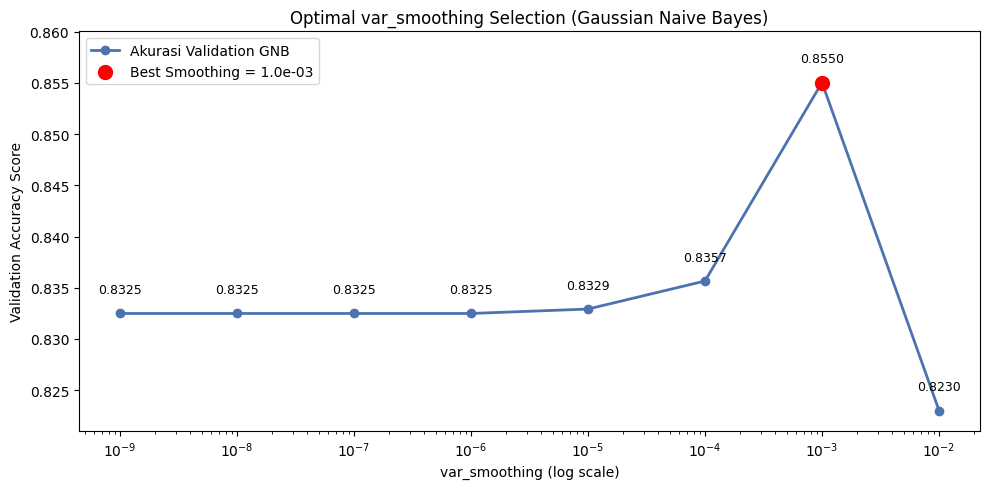

In [16]:
# Pastikan results_gnb sudah dalam bentuk DataFrame
results_df_gnb = pd.DataFrame(results_gnb, columns=["var_smoothing", "accuracy"])

plt.figure(figsize=(10, 5))

plt.style.use('default')
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['figure.facecolor'] = 'white'

plt.plot(results_df_gnb["var_smoothing"],
         results_df_gnb["accuracy"],
         marker='o',
         markersize=6,
         linewidth=2,
         color='#4C72B0',
         label="Akurasi Validation GNB")

plt.scatter(best_params_gnb['var_smoothing'],
            best_acc_gnb,
            color='red',
            s=100,
            zorder=5,
            label=f"Best Smoothing = {best_params_gnb['var_smoothing']:.1e}")

plt.ylim(results_df_gnb["accuracy"].min() - 0.002,
         results_df_gnb["accuracy"].max() + 0.005)

# Font normal
for i in range(len(results_df_gnb)):
    plt.text(results_df_gnb["var_smoothing"][i],
             results_df_gnb["accuracy"][i] + 0.002,
             f"{results_df_gnb['accuracy'][i]:.4f}",
             ha='center',
             fontsize=9)

plt.xscale("log")

plt.title("Optimal var_smoothing Selection (Gaussian Naive Bayes)")
plt.xlabel("var_smoothing (log scale)")
plt.ylabel("Validation Accuracy Score")

plt.legend()
plt.tight_layout()
plt.savefig("gnb_parameter_optimized1.png", dpi=300, bbox_inches='tight')
plt.show()

# Akurasi GNB

In [17]:
print("\n" + "=" * 70)
print("FINAL TRAINING (Train + Validation) - Gaussian Naive Bayes")
print("=" * 70)

# 1. Gunakan best_params_gnb yang tadi sudah disimpan dari proses tuning
# 2. Train ulang pakai data gabungan (Train + Validation) agar model lebih 'berpengalaman'
final_gnb = GaussianNB(**best_params_gnb)
final_gnb.fit(X_train_full, y_train_full)

# 3. Prediksi di Test Set (Data yang tidak pernah dilihat model sama sekali)
y_test_pred_gnb = final_gnb.predict(X_test)

# 4. Hitung akurasi test
test_acc_gnb = accuracy_score(y_test, y_test_pred_gnb)

print(f"Model GNB yang digunakan    : {best_params_gnb}")
print(f"Test Accuracy (Final Model) : {test_acc_gnb:.4f}")
print("=" * 70)


FINAL TRAINING (Train + Validation) - Gaussian Naive Bayes
Model GNB yang digunakan    : {'var_smoothing': np.float64(0.001)}
Test Accuracy (Final Model) : 0.8546


# Confusion Matrix GNB

In [18]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, roc_auc_score, classification_report

print("\n" + "=" * 70)
print("EVALUASI MODEL AKHIR - Gaussian Naive Bayes (Data Test)")
print("=" * 70)

# 1. Proses Prediksi (Membuat variabel baru khusus untuk GNB)
y_test_pred_gnb = final_gnb.predict(X_test)
y_test_prob_gnb = final_gnb.predict_proba(X_test)

# 2. Confusion Matrix (Menggunakan hasil prediksi GNB)
cm_gnb = confusion_matrix(y_test, y_test_pred_gnb)

# 3. Metrik Evaluasi (Weighted untuk Multiclass)
precision_gnb = precision_score(y_test, y_test_pred_gnb, average='weighted')
recall_gnb = recall_score(y_test, y_test_pred_gnb, average='weighted')
roc_auc_gnb = roc_auc_score(y_test, y_test_prob_gnb, multi_class='ovr', average='weighted')

print("Confusion Matrix (GNB):")
print(cm_gnb)

print("\nMetrik Ringkasan (Data Test):")
print(f"Precision : {precision_gnb:.4f}")
print(f"Recall    : {recall_gnb:.4f}")
print(f"ROC AUC   : {roc_auc_gnb:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_gnb))

print("=" * 70)


EVALUASI MODEL AKHIR - Gaussian Naive Bayes (Data Test)
Confusion Matrix (GNB):
[[ 9  0  0 ...  0  0  0]
 [ 0 74  0 ...  0  0  0]
 [ 0  0 16 ...  0  0  0]
 ...
 [ 0  0  0 ... 37  0  0]
 [ 0  0  0 ...  0 38  0]
 [ 0  0  0 ...  0  0 59]]

Metrik Ringkasan (Data Test):
Precision : 0.8755
Recall    : 0.8546
ROC AUC   : 0.9638

Classification Report:
                               precision    recall  f1-score   support

                       4-29-1       0.90      0.69      0.78        13
                         ABY1       1.00      0.97      0.99        76
                          AD3       1.00      0.89      0.94        18
               Abditibacteria       1.00      0.97      0.98        32
                Acetothermiia       1.00      0.94      0.97        32
               Acidimicrobiia       0.96      0.96      0.96       480
               Acidobacteriae       1.00      0.93      0.96       641
               Actinobacteria       0.99      0.86      0.92      3600
           

# Data Frame Aktual Prediksi GNB

In [19]:
df_pred_gnb = pd.DataFrame({
    'Aktual': y_test,
    'Prediksi': y_test_pred_gnb
})

df_pred_gnb.index = df_pred_gnb.index + 1
df_pred_gnb.head(10)

,Aktual,Prediksi
1,Gammaproteobacteria,Gammaproteobacteria
2,Bacilli,Clostridia
3,Desulfobulbia,Desulfobulbia
4,Clostridia,Clostridia
5,Gammaproteobacteria,Gammaproteobacteria
6,Alphaproteobacteria,Alphaproteobacteria
7,Kiritimatiellae,Kiritimatiellae
8,Alphaproteobacteria,Alphaproteobacteria
9,Actinobacteria,Actinobacteria
10,Gammaproteobacteria,Gammaproteobacteria


In [20]:
df_pred_gnb = pd.DataFrame({
    'Aktual': y_test,
    'Prediksi': y_test_pred_gnb
})

df_pred_gnb.index = df_pred_gnb.index + 1
df_pred_gnb.tail(10)

,Aktual,Prediksi
55509,Gammaproteobacteria,Gammaproteobacteria
55510,Bacteroidia,Parcubacteria
55511,Bacilli,Clostridia
55512,Desulfobacteria,Desulfobacteria
55513,Bacteroidia,Bacteroidia
55514,Cyanobacteriia,Cyanobacteriia
55515,Bacilli,Bacilli
55516,Planctomycetes,Planctomycetes
55517,Bacilli,Clostridia
55518,Gammaproteobacteria,Gammaproteobacteria


# Visualisasi Confusion Matrix GNB


CONFUSION MATRIX GNB (10 KELAS TERATAS)


,4-29-1,ABY1,AD3,Abditibacteria,Acetothermiia,Acidimicrobiia,Acidobacteriae,Actinobacteria,Aerophobia,Alphaproteobacteria
4-29-1,9,0,0,0,0,0,0,0,0,0
ABY1,0,74,0,0,0,0,0,0,0,0
AD3,0,0,16,0,0,0,0,0,0,0
Abditibacteria,0,0,0,31,0,0,0,0,0,0
Acetothermiia,0,0,0,0,30,0,0,0,0,0
Acidimicrobiia,0,0,0,0,0,460,0,1,0,0
Acidobacteriae,1,0,0,0,0,0,596,0,0,0
Actinobacteria,0,0,0,0,0,13,0,3091,0,0
Aerophobia,0,0,0,0,0,0,0,0,12,0
Alphaproteobacteria,0,0,0,0,0,1,0,0,0,4071



CONFUSION MATRIX GNB (10 KELAS TERBAWAH)


,Vicinamibacteria,WCHB1-81,WOR-1,WPS-2,WS1,WS2,Zetaproteobacteria,Zixibacteria,bacteriap25,vadinHA49
Vicinamibacteria,268,0,0,0,0,0,0,0,0,0
WCHB1-81,0,16,0,0,0,0,0,0,0,0
WOR-1,0,0,6,0,0,0,0,0,0,0
WPS-2,0,0,0,7,0,0,0,0,0,0
WS1,0,0,0,0,13,0,0,0,0,0
WS2,0,0,0,0,0,11,0,0,0,0
Zetaproteobacteria,0,0,0,0,0,0,24,0,0,0
Zixibacteria,0,0,0,0,0,0,0,37,0,0
bacteriap25,0,0,0,0,0,0,0,0,38,0
vadinHA49,0,0,0,0,0,0,0,0,0,59


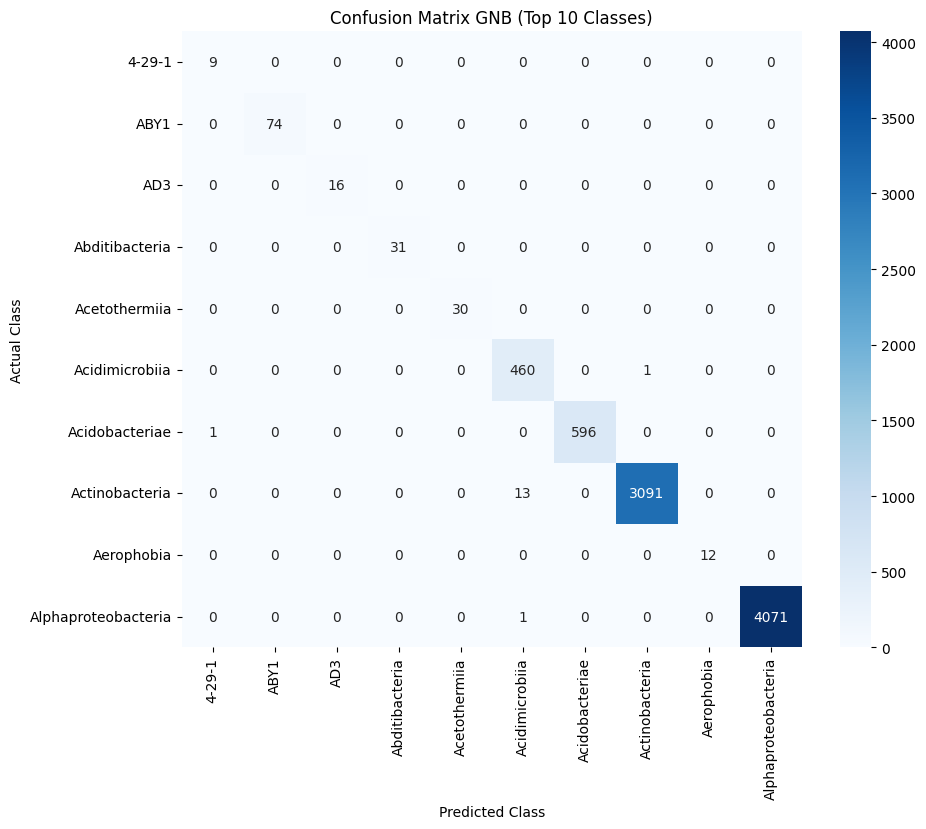

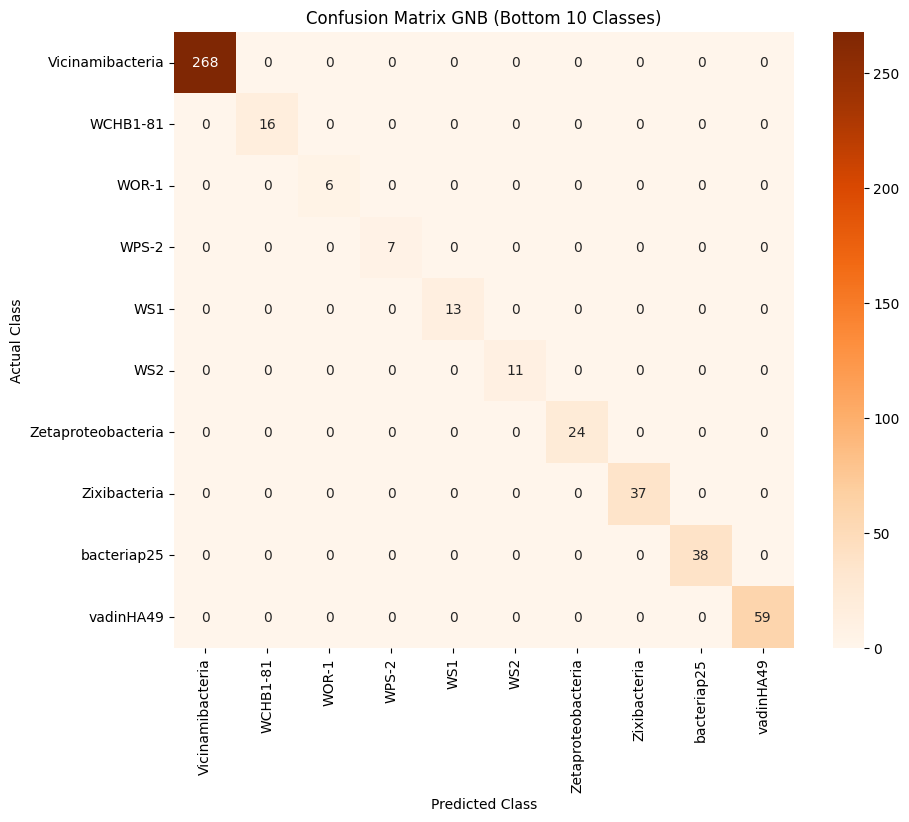


File berhasil disimpan di Kaggle:
/kaggle/working/confusion_matrix_gnb_top10.png
/kaggle/working/confusion_matrix_gnb_bottom10.png


In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# GUNAKAN cm_gnb YANG SUDAH ADA
# =========================

labels = sorted(set(y_test))

cm_df_gnb = pd.DataFrame(cm_gnb, index=labels, columns=labels)

print("\n" + "="*70)
print("CONFUSION MATRIX GNB (10 KELAS TERATAS)")
print("="*70)

cm_top10_gnb = cm_df_gnb.iloc[:10, :10]
display(cm_top10_gnb)

print("\n" + "="*70)
print("CONFUSION MATRIX GNB (10 KELAS TERBAWAH)")
print("="*70)

cm_bottom10_gnb = cm_df_gnb.iloc[-10:, -10:]
display(cm_bottom10_gnb)

# =========================
# HEATMAP TOP 10
# =========================
plt.figure(figsize=(10,8))

sns.heatmap(
    cm_top10_gnb,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix GNB (Top 10 Classes)")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.savefig("/kaggle/working/confusion_matrix_gnb_top10.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

# =========================
# HEATMAP BOTTOM 10
# =========================
plt.figure(figsize=(10,8))

sns.heatmap(
    cm_bottom10_gnb,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("Confusion Matrix GNB (Bottom 10 Classes)")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.savefig("/kaggle/working/confusion_matrix_gnb_bottom10.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

print("\nFile berhasil disimpan di Kaggle:")
print("/kaggle/working/confusion_matrix_gnb_top10.png")
print("/kaggle/working/confusion_matrix_gnb_bottom10.png")

# Visualisasi ROC AUC GNB

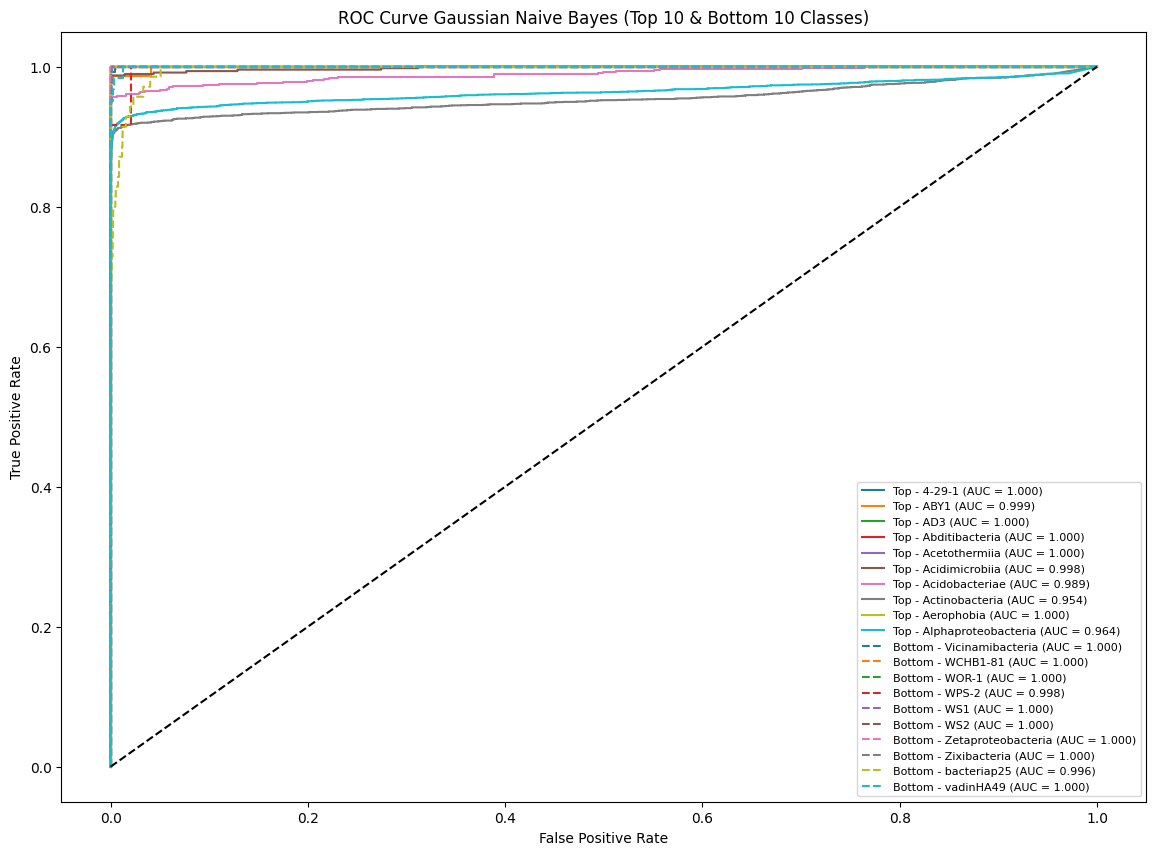

ROC curve tersimpan di: /kaggle/working/roc_gnb_top_bottom_classes.png


In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# =========================
# SETUP KELAS
# =========================
classes = final_gnb.classes_

top10_classes = classes[:10]
bottom10_classes = classes[-10:]

plt.figure(figsize=(14,10))

# =========================
# ROC TOP 10
# =========================
for cls in top10_classes:
    
    idx = np.where(classes == cls)[0][0]
    
    y_true = (y_test == cls).astype(int)
    y_score = y_test_prob_gnb[:, idx]

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr, tpr,
        label=f"Top - {cls} (AUC = {roc_auc:.3f})"
    )

# =========================
# ROC BOTTOM 10
# =========================
for cls in bottom10_classes:
    
    idx = np.where(classes == cls)[0][0]

    y_true = (y_test == cls).astype(int)
    y_score = y_test_prob_gnb[:, idx]

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr, tpr,
        linestyle="--",
        label=f"Bottom - {cls} (AUC = {roc_auc:.3f})"
    )

# garis random classifier
plt.plot([0,1],[0,1],'k--')

plt.title("ROC Curve Gaussian Naive Bayes (Top 10 & Bottom 10 Classes)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend(fontsize=8)

# =========================
# SIMPAN
# =========================
plt.savefig("/kaggle/working/roc_gnb_top_bottom_classes.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

print("ROC curve tersimpan di: /kaggle/working/roc_gnb_top_bottom_classes.png")

# 3. Analisis Perbandingan Model KNN 

# ROC AUC KNN DAN GNB

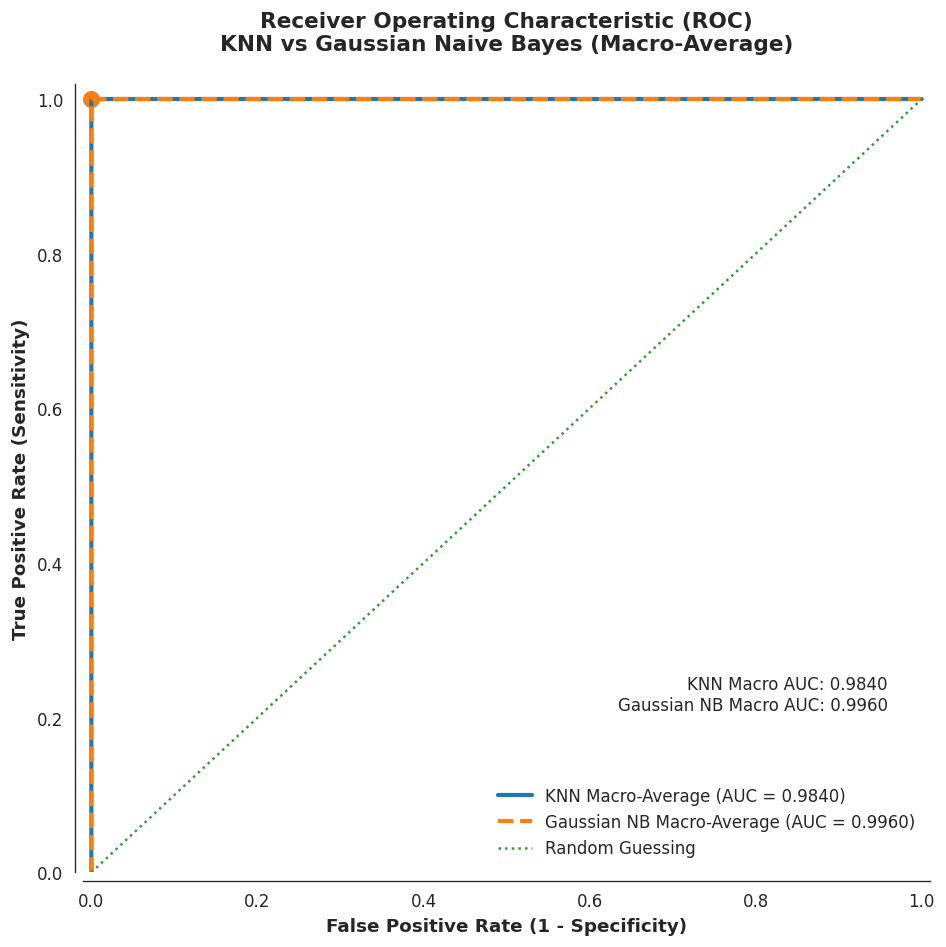

AUC KNN (Macro)         : 0.9840
AUC Gaussian NB (Macro) : 0.9960
Waktu eksekusi          : 935.73 detik


In [23]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time

start_time = time.time()

# ==============================
# 1. PREDICT PROBABILITIES (CPU)
# ==============================

y_probs_knn = final_knn.predict_proba(X_test)
y_probs_gnb = final_gnb.predict_proba(X_test)

# ==============================
# 2. BINARIZE LABEL (MULTICLASS)
# ==============================

classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

# ==============================
# 3. FUNCTION ROC MACRO-AVERAGE
# ==============================

def get_macro_auc(y_true_bin, y_score, classes):
    auc_list = []
    fpr_dict = {}
    tpr_dict = {}

    for i in range(len(classes)):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        auc_list.append(roc_auc)

        fpr_dict[i] = fpr
        tpr_dict[i] = tpr

    macro_auc = np.mean(auc_list)
    return macro_auc, fpr_dict, tpr_dict

auc_knn_val, fpr_knn_dict, tpr_knn_dict = get_macro_auc(y_test_bin, y_probs_knn, classes)
auc_gnb_val, fpr_gnb_dict, tpr_gnb_dict = get_macro_auc(y_test_bin, y_probs_gnb, classes)

# ==============================
# 4. VISUALISASI ROC (Ambil kelas pertama utk plotting)
# ==============================

plt.figure(figsize=(8, 8), dpi=120)
sns.set_style("white")

# Ambil kurva kelas pertama hanya untuk visualisasi
plt.plot(fpr_knn_dict[0], tpr_knn_dict[0],
         lw=2.5,
         label=f'KNN Macro-Average (AUC = {auc_knn_val:.4f})')

plt.plot(fpr_gnb_dict[0], tpr_gnb_dict[0],
         lw=2.5, linestyle='--',
         label=f'Gaussian NB Macro-Average (AUC = {auc_gnb_val:.4f})')

# Titik Optimal (Youden Index - kelas pertama)
idx_knn = np.argmax(tpr_knn_dict[0] - fpr_knn_dict[0])
idx_gnb = np.argmax(tpr_gnb_dict[0] - fpr_gnb_dict[0])

plt.scatter(fpr_knn_dict[0][idx_knn], tpr_knn_dict[0][idx_knn], s=80)
plt.scatter(fpr_gnb_dict[0][idx_gnb], tpr_gnb_dict[0][idx_gnb], s=80)

# Baseline
plt.plot([0, 1], [0, 1],
         lw=1.5, linestyle=':',
         label='Random Guessing')

plt.xlim([-0.01, 1.01])
plt.ylim([0.0, 1.02])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11, fontweight='bold')
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=11, fontweight='bold')

plt.title('Receiver Operating Characteristic (ROC)\nKNN vs Gaussian Naive Bayes (Macro-Average)',
          fontsize=13, pad=20, fontweight='bold')

plt.legend(loc='lower right', frameon=False)
sns.despine(offset=5)

# Ringkasan AUC
perf_text = f"KNN Macro AUC: {auc_knn_val:.4f}\nGaussian NB Macro AUC: {auc_gnb_val:.4f}"
plt.text(0.95, 0.25, perf_text,
         ha='right', va='top',
         fontsize=10,
         bbox=dict(boxstyle='round,pad=0.5',
                   fc='white', alpha=0.9),
         transform=plt.gca().transAxes)

plt.tight_layout()
plt.savefig('roc_auc_knn_vs_gnb_macro.png', dpi=300, bbox_inches='tight')
plt.show()

end_time = time.time()

print("=" * 70)
print(f"AUC KNN (Macro)         : {auc_knn_val:.4f}")
print(f"AUC Gaussian NB (Macro) : {auc_gnb_val:.4f}")
print(f"Waktu eksekusi          : {end_time - start_time:.2f} detik")
print("=" * 70)

# Visualisasi RADAR CHART

✅ Metrik MACRO berhasil dihitung


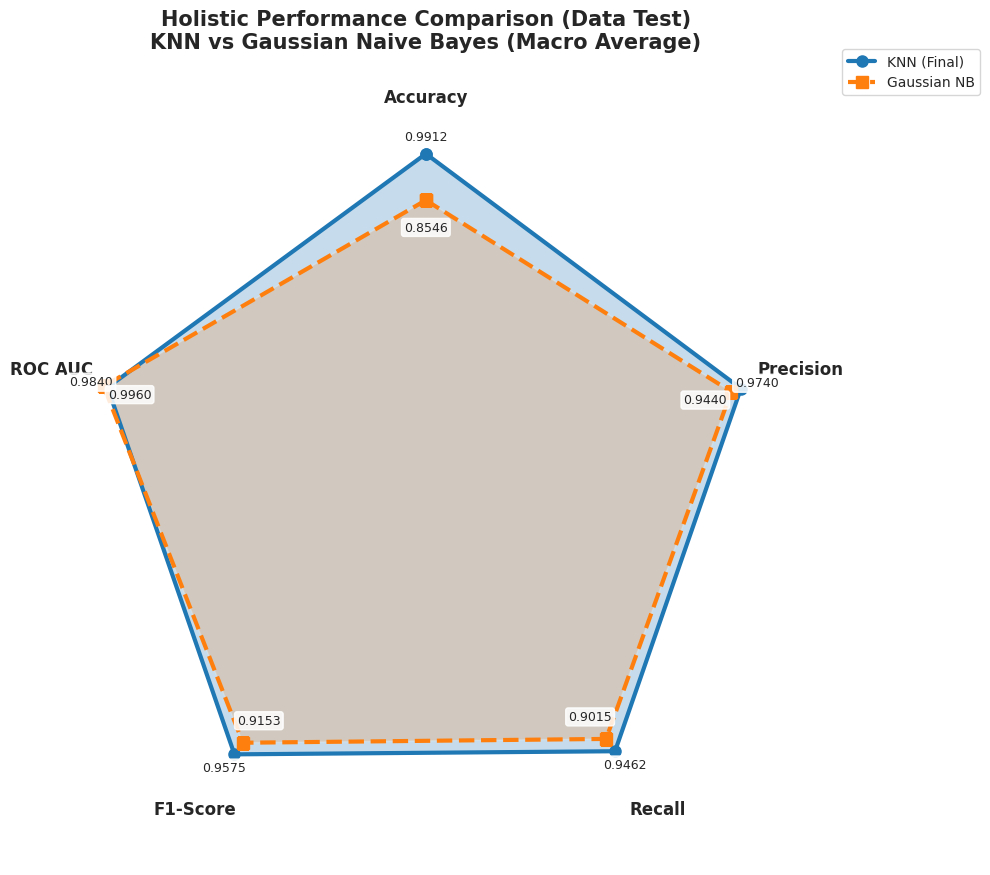

✅ Radar chart multiclass (MACRO) berhasil dibuat!


In [24]:
# =============================================================================
# FINAL RADAR CHART - MULTICLASS (MACRO VERSION - 1 CELL FIX)
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# =====================================================
# 1. HITUNG METRIK (MACRO AVERAGE)
# =====================================================

# --- KNN ---
accuracy_knn = accuracy_score(y_test, y_test_pred_knn)
precision_knn = precision_score(y_test, y_test_pred_knn, average='macro')
recall_knn = recall_score(y_test, y_test_pred_knn, average='macro')
f1_knn = f1_score(y_test, y_test_pred_knn, average='macro')
roc_auc_knn = roc_auc_score(y_test, y_test_prob_knn, multi_class='ovr', average='macro')

# --- GNB ---
accuracy_gnb = accuracy_score(y_test, y_test_pred_gnb)
precision_gnb = precision_score(y_test, y_test_pred_gnb, average='macro')
recall_gnb = recall_score(y_test, y_test_pred_gnb, average='macro')
f1_gnb = f1_score(y_test, y_test_pred_gnb, average='macro')
roc_auc_gnb = roc_auc_score(y_test, y_test_prob_gnb, multi_class='ovr', average='macro')

print("✅ Metrik MACRO berhasil dihitung")

# =====================================================
# 2. SETUP RADAR DATA
# =====================================================

labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC']
num_vars = len(labels)

knn_stats_values = [accuracy_knn, precision_knn, recall_knn, f1_knn, roc_auc_knn]
gnb_stats_values = [accuracy_gnb, precision_gnb, recall_gnb, f1_gnb, roc_auc_gnb]

knn_plot_values = knn_stats_values + [knn_stats_values[0]]
gnb_plot_values = gnb_stats_values + [gnb_stats_values[0]]

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

# =====================================================
# 3. PLOTTING
# =====================================================

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

# Hilangkan grid & border
ax.spines['polar'].set_visible(False)
ax.grid(False)
ax.set_yticks([])
ax.set_yticklabels([])

# Plot KNN
ax.plot(angles, knn_plot_values, linewidth=3, marker='o', markersize=8, label='KNN (Final)')
ax.fill(angles, knn_plot_values, alpha=0.25)

# Plot GNB
ax.plot(angles, gnb_plot_values, linewidth=3, linestyle='--', marker='s', markersize=8, label='Gaussian NB')
ax.fill(angles, gnb_plot_values, alpha=0.2)

# Data Labels
for i, angle in enumerate(angles[:-1]):
    ax.text(angle, knn_stats_values[i] + 0.05,
            f'{knn_stats_values[i]:.4f}',
            ha='center', va='center', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.85))

    ax.text(angle, gnb_stats_values[i] - 0.08,
            f'{gnb_stats_values[i]:.4f}',
            ha='center', va='center', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.85))

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=12, fontweight='bold')

ax.set_ylim(0, 1.1)

plt.title("Holistic Performance Comparison (Data Test)\nKNN vs Gaussian Naive Bayes (Macro Average)",
          size=15, fontweight='bold', y=1.08)

plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1))

plt.tight_layout()
plt.savefig('radar_chart_macro_multiclass.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Radar chart multiclass (MACRO) berhasil dibuat!")

# Visualisasi Confidence Score

Shape Probabilitas KNN : (55518, 178)
Shape Probabilitas GNB : (55518, 178)

Contoh probabilitas KNN (5 sampel pertama):
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 

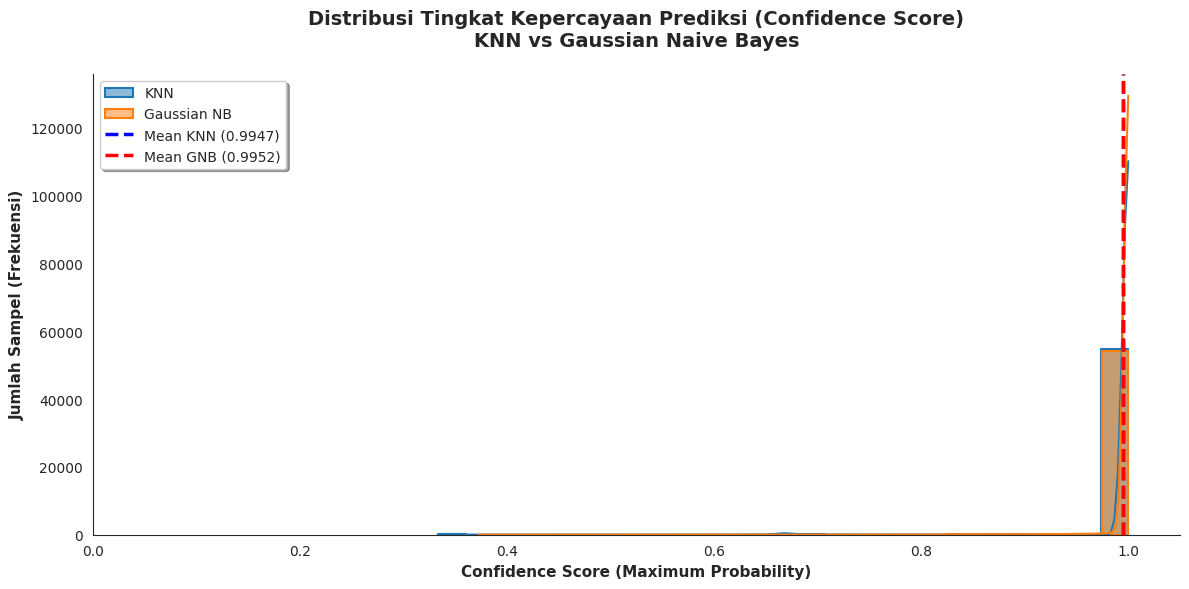


ANALISIS TINGKAT KEPERCAYAAN MODEL
K-Nearest Neighbors   | Rata-rata Confidence: 0.9947
Gaussian Naive Bayes  | Rata-rata Confidence: 0.9952
----------------------------------------------------------------------
File tersimpan di: /kaggle/working/confidence_score_dist_clean.png


In [25]:
# =============================================================================
# VISUALISASI CONFIDENCE SCORE - CLEAN WHITE BACKGROUND
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================================
# HITUNG PROBABILITAS PREDIKSI MODEL
# =============================================================================

# Probabilitas prediksi KNN
y_prob_knn = final_knn.predict_proba(X_test)

# Probabilitas prediksi Gaussian Naive Bayes
y_prob_gnb = final_gnb.predict_proba(X_test)

print("Shape Probabilitas KNN :", y_prob_knn.shape)
print("Shape Probabilitas GNB :", y_prob_gnb.shape)

print("\nContoh probabilitas KNN (5 sampel pertama):")
print(y_prob_knn[:5])

print("\nContoh probabilitas GNB (5 sampel pertama):")
print(y_prob_gnb[:5])

# =============================================================================
# HITUNG CONFIDENCE SCORE
# =============================================================================

# Confidence = probabilitas tertinggi dari setiap sampel
confidence_knn = np.max(y_prob_knn, axis=1)
confidence_gnb = np.max(y_prob_gnb, axis=1)

# Mean confidence
mean_knn = np.mean(confidence_knn)
mean_gnb = np.mean(confidence_gnb)

# =============================================================================
# VISUALISASI DISTRIBUSI CONFIDENCE
# =============================================================================

plt.figure(figsize=(12, 6), dpi=100)
sns.set_style("white")

sns.histplot(confidence_knn, bins=25, kde=True,
             color='#1f77b4', label='KNN',
             alpha=0.5, element="step", linewidth=1.5)

sns.histplot(confidence_gnb, bins=25, kde=True,
             color='#ff7f0e', label='Gaussian NB',
             alpha=0.5, element="step", linewidth=1.5)

# Garis rata-rata
plt.axvline(mean_knn, color='blue', linestyle='--', lw=2.5,
            label=f'Mean KNN ({mean_knn:.4f})')

plt.axvline(mean_gnb, color='red', linestyle='--', lw=2.5,
            label=f'Mean GNB ({mean_gnb:.4f})')

plt.xlabel("Confidence Score (Maximum Probability)", fontsize=11, fontweight='bold')
plt.ylabel("Jumlah Sampel (Frekuensi)", fontsize=11, fontweight='bold')

plt.title("Distribusi Tingkat Kepercayaan Prediksi (Confidence Score)\nKNN vs Gaussian Naive Bayes",
          fontsize=14, pad=20, fontweight='bold')

plt.xlim([0, 1.05])
sns.despine()

plt.legend(loc='upper left', frameon=True, shadow=True, fontsize=10)

# Simpan
plt.savefig('/kaggle/working/confidence_score_dist_clean.png',
            dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

# =============================================================================
# RINGKASAN ANALISIS
# =============================================================================
print("\n" + "="*70)
print("ANALISIS TINGKAT KEPERCAYAAN MODEL")
print("="*70)
print(f"K-Nearest Neighbors   | Rata-rata Confidence: {mean_knn:.4f}")
print(f"Gaussian Naive Bayes  | Rata-rata Confidence: {mean_gnb:.4f}")
print("-" * 70)
print("File tersimpan di: /kaggle/working/confidence_score_dist_clean.png")
print("="*70)

Shape Probabilitas KNN : (55518, 178)
Shape Probabilitas GNB : (55518, 178)

Contoh probabilitas KNN (5 sampel pertama):
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 

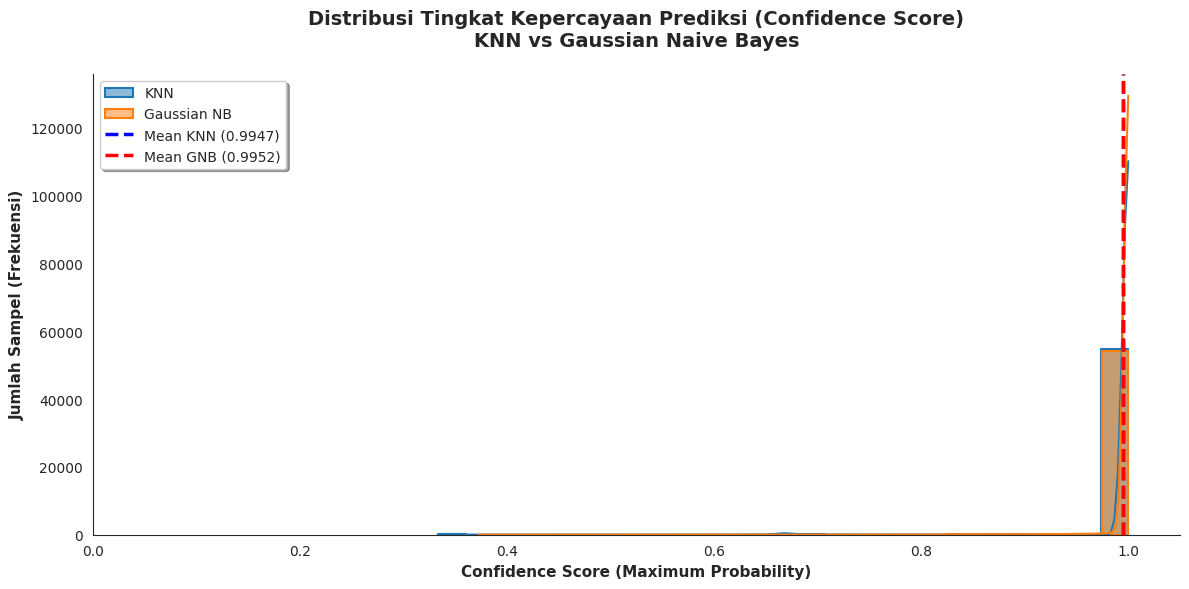


ANALISIS TINGKAT KEPERCAYAAN MODEL
K-Nearest Neighbors   | Rata-rata Confidence: 0.9947
Gaussian Naive Bayes  | Rata-rata Confidence: 0.9952
----------------------------------------------------------------------
File tersimpan di: /kaggle/working/confidence_score_dist_clean.png


In [26]:
# =============================================================================
# VISUALISASI CONFIDENCE SCORE - CLEAN WHITE BACKGROUND
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================================
# HITUNG PROBABILITAS PREDIKSI MODEL
# =============================================================================

# Probabilitas prediksi KNN
y_prob_knn = final_knn.predict_proba(X_test)

# Probabilitas prediksi Gaussian Naive Bayes
y_prob_gnb = final_gnb.predict_proba(X_test)

print("Shape Probabilitas KNN :", y_prob_knn.shape)
print("Shape Probabilitas GNB :", y_prob_gnb.shape)

print("\nContoh probabilitas KNN (5 sampel pertama):")
print(y_prob_knn[:5])

print("\nContoh probabilitas GNB (5 sampel pertama):")
print(y_prob_gnb[:5])

# =============================================================================
# HITUNG CONFIDENCE SCORE
# =============================================================================

# Confidence = probabilitas tertinggi dari setiap sampel
confidence_knn = np.max(y_prob_knn, axis=1)
confidence_gnb = np.max(y_prob_gnb, axis=1)

# Mean confidence
mean_knn = np.mean(confidence_knn)
mean_gnb = np.mean(confidence_gnb)

# =============================================================================
# VISUALISASI DISTRIBUSI CONFIDENCE
# =============================================================================

plt.figure(figsize=(12, 6), dpi=100)
sns.set_style("white")

sns.histplot(confidence_knn, bins=25, kde=True,
             color='#1f77b4', label='KNN',
             alpha=0.5, element="step", linewidth=1.5)

sns.histplot(confidence_gnb, bins=25, kde=True,
             color='#ff7f0e', label='Gaussian NB',
             alpha=0.5, element="step", linewidth=1.5)

# Garis rata-rata
plt.axvline(mean_knn, color='blue', linestyle='--', lw=2.5,
            label=f'Mean KNN ({mean_knn:.4f})')

plt.axvline(mean_gnb, color='red', linestyle='--', lw=2.5,
            label=f'Mean GNB ({mean_gnb:.4f})')

plt.xlabel("Confidence Score (Maximum Probability)", fontsize=11, fontweight='bold')
plt.ylabel("Jumlah Sampel (Frekuensi)", fontsize=11, fontweight='bold')

plt.title("Distribusi Tingkat Kepercayaan Prediksi (Confidence Score)\nKNN vs Gaussian Naive Bayes",
          fontsize=14, pad=20, fontweight='bold')

plt.xlim([0, 1.05])
sns.despine()

plt.legend(loc='upper left', frameon=True, shadow=True, fontsize=10)

# Simpan
plt.savefig('/kaggle/working/confidence_score_dist_clean.png',
            dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

# =============================================================================
# RINGKASAN ANALISIS
# =============================================================================
print("\n" + "="*70)
print("ANALISIS TINGKAT KEPERCAYAAN MODEL")
print("="*70)
print(f"K-Nearest Neighbors   | Rata-rata Confidence: {mean_knn:.4f}")
print(f"Gaussian Naive Bayes  | Rata-rata Confidence: {mean_gnb:.4f}")
print("-" * 70)
print("File tersimpan di: /kaggle/working/confidence_score_dist_clean.png")
print("="*70)

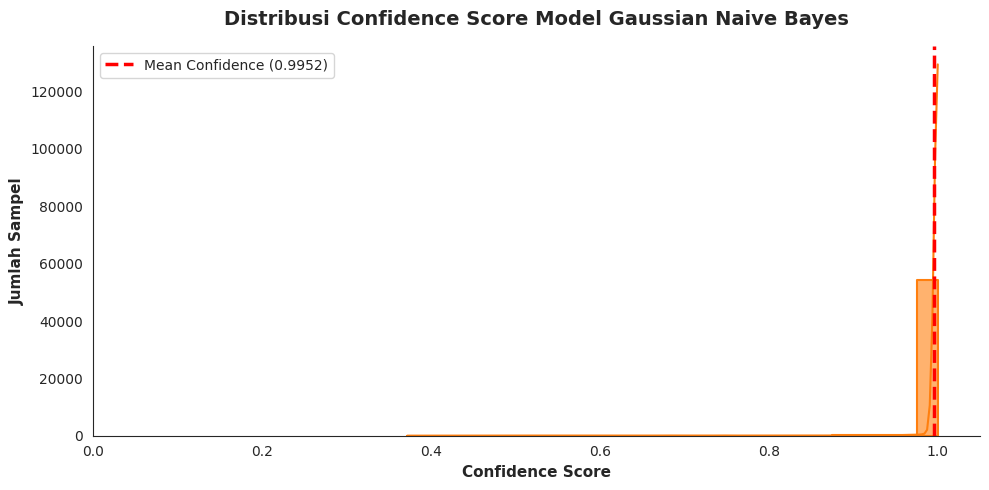

In [27]:
# =============================================================================
# VISUALISASI CONFIDENCE SCORE GAUSSIAN NB
# =============================================================================
mean_gnb = np.mean(confidence_gnb)

plt.figure(figsize=(10,5), dpi=100)
sns.set_style("white")

sns.histplot(confidence_gnb,
             bins=25,
             kde=True,
             color='#ff7f0e',
             alpha=0.6,
             element="step",
             linewidth=1.5)

plt.axvline(mean_gnb,
            color='red',
            linestyle='--',
            lw=2.5,
            label=f'Mean Confidence ({mean_gnb:.4f})')

plt.xlabel("Confidence Score", fontsize=11, fontweight='bold')
plt.ylabel("Jumlah Sampel", fontsize=11, fontweight='bold')

plt.title("Distribusi Confidence Score Model Gaussian Naive Bayes",
          fontsize=14,
          fontweight='bold',
          pad=15)

plt.xlim([0,1.05])
sns.despine()

plt.legend()
plt.tight_layout()
plt.show()

# Multiclass Evaluasi Model

In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# =====================================================
# HITUNG METRIK (MULTICLASS - MACRO)
# =====================================================

# --- KNN ---
acc_knn = accuracy_score(y_test, y_test_pred_knn)
prec_knn = precision_score(y_test, y_test_pred_knn, average='macro')
rec_knn = recall_score(y_test, y_test_pred_knn, average='macro')
f1_knn = f1_score(y_test, y_test_pred_knn, average='macro')
roc_knn = roc_auc_score(y_test, y_test_prob_knn, multi_class='ovr', average='macro')

# --- GNB ---
acc_gnb = accuracy_score(y_test, y_test_pred_gnb)
prec_gnb = precision_score(y_test, y_test_pred_gnb, average='macro')
rec_gnb = recall_score(y_test, y_test_pred_gnb, average='macro')
f1_gnb = f1_score(y_test, y_test_pred_gnb, average='macro')
roc_gnb = roc_auc_score(y_test, y_test_prob_gnb, multi_class='ovr', average='macro')

# Confusion Matrix
cm_knn = confusion_matrix(y_test, y_test_pred_knn)
cm_gnb = confusion_matrix(y_test, y_test_pred_gnb)

# =====================================================
# TABEL RINGKASAN EVALUASI (MACRO)
# =====================================================

print("="*75)
print(f"{'METRIK EVALUASI (MULTICLASS - MACRO)':<35} | {'KNN MODEL':<15} | {'GNB MODEL':<15}")
print("="*75)

print(f"{'Accuracy Score':<35} | {acc_knn:<15.4f} | {acc_gnb:<15.4f}")
print(f"{'Precision (Macro)':<35} | {prec_knn:<15.4f} | {prec_gnb:<15.4f}")
print(f"{'Recall (Macro)':<35} | {rec_knn:<15.4f} | {rec_gnb:<15.4f}")
print(f"{'F1-Score (Macro)':<35} | {f1_knn:<15.4f} | {f1_gnb:<15.4f}")
print(f"{'ROC AUC (OvR - Macro)':<35} | {roc_knn:<15.4f} | {roc_gnb:<15.4f}")
print("-"*75)
print(f"{'Total Execution Time (s)':<35} | {duration_knn:<15.4f} | {duration_gnb:<15.4f}")
print("="*75)

# =====================================================
# CONFUSION MATRIX
# =====================================================

print("\nConfusion Matrix - KNN:")
print(cm_knn)

print("\nConfusion Matrix - Gaussian Naive Bayes:")
print(cm_gnb)

print("\n✅ Evaluasi multiclass dengan MACRO average berhasil dibuat!")

METRIK EVALUASI (MULTICLASS - MACRO) | KNN MODEL       | GNB MODEL      
Accuracy Score                      | 0.9912          | 0.8546         
Precision (Macro)                   | 0.9740          | 0.9440         
Recall (Macro)                      | 0.9462          | 0.9015         
F1-Score (Macro)                    | 0.9575          | 0.9153         
ROC AUC (OvR - Macro)               | 0.9840          | 0.9960         
---------------------------------------------------------------------------
Total Execution Time (s)            | 1735.8914       | 534.8030       

Confusion Matrix - KNN:
[[13  0  0 ...  0  0  0]
 [ 0 66  0 ...  0  0  0]
 [ 0  0 17 ...  0  0  0]
 ...
 [ 0  0  0 ... 37  0  0]
 [ 0  0  0 ...  0 51  0]
 [ 0  0  0 ...  0  0 60]]

Confusion Matrix - Gaussian Naive Bayes:
[[ 9  0  0 ...  0  0  0]
 [ 0 74  0 ...  0  0  0]
 [ 0  0 16 ...  0  0  0]
 ...
 [ 0  0  0 ... 37  0  0]
 [ 0  0  0 ...  0 38  0]
 [ 0  0  0 ...  0  0 59]]

✅ Evaluasi multiclass dengan MACRO aver

In [29]:
# =========================
# HITUNG TP, TN, FP, FN
# =========================
labels = sorted(set(y_test))
cm = cm_knn
n_classes = len(labels)

tp_list, tn_list, fp_list, fn_list = [], [], [], []

for i in range(n_classes):
    tp = cm[i, i]
    fp = cm[:, i].sum() - tp
    fn = cm[i, :].sum() - tp
    tn = cm.sum() - tp - fp - fn
    tp_list.append(tp)
    tn_list.append(tn)
    fp_list.append(fp)
    fn_list.append(fn)

metrics_df = pd.DataFrame({
    "Class" : labels,
    "TP"    : tp_list,
    "TN"    : tn_list,
    "FP"    : fp_list,
    "FN"    : fn_list,
}).set_index("Class")

# =========================
# TOP 10
# =========================
print("\n" + "="*50)
print("TP/TN/FP/FN KNN — 10 KELAS TERATAS")
print("="*50)
display(metrics_df.head(10))

# =========================
# BOTTOM 10
# =========================
print("\n" + "="*50)
print("TP/TN/FP/FN KNN — 10 KELAS TERBAWAH")
print("="*50)
display(metrics_df.tail(10))


TP/TN/FP/FN KNN — 10 KELAS TERATAS


,TP,TN,FP,FN
Class,,,,
4-29-1,13,55504,1,0
ABY1,66,55442,0,10
AD3,17,55500,0,1
Abditibacteria,32,55486,0,0
Acetothermiia,31,55486,0,1
Acidimicrobiia,474,55035,3,6
Acidobacteriae,637,54876,1,4
Actinobacteria,3593,51890,28,7
Aerophobia,13,55505,0,0



TP/TN/FP/FN KNN — 10 KELAS TERBAWAH


,TP,TN,FP,FN
Class,,,,
Vicinamibacteria,278,55238,0,2
WCHB1-81,17,55501,0,0
WOR-1,6,55511,0,1
WPS-2,9,55506,0,3
WS1,14,55504,0,0
WS2,10,55507,0,1
Zetaproteobacteria,24,55494,0,0
Zixibacteria,37,55479,0,2
bacteriap25,51,55441,7,19
